<a href="https://colab.research.google.com/github/DevinTang-cs/first-repo/blob/bert-test/tf_idf_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import jieba
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from datasets import load_dataset
import matplotlib.pyplot as plt
import random

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
# -----------------------------
# 0. PyTorch Dataset 类定义 (必须在 DataLoader 之前定义)
# -----------------------------
class TextDataset(Dataset):
    """自定义 PyTorch Dataset 类，用于封装特征矩阵 X 和标签 y"""
    def __init__(self, X, y):
        # 将 numpy 数组转换为 PyTorch Tensor，确保数据类型正确
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) # 标签是长整型 (Long)

    def __len__(self):
        # 返回数据集大小
        return len(self.X)

    def __getitem__(self, idx):
        # 根据索引返回特征和标签
        return self.X[idx], self.y[idx]

In [ ]:
# -----------------------------
# 1. 数据加载与类别筛选
# -----------------------------
print("--- 1. 数据加载 ---")
# 加载 CLUE 官方新闻分类数据 (TNEWS)，数据量约 3.1 万条
dataset = load_dataset("clue", "tnews")
# 提取文本内容 (sentence) 和原始标签 (label)
texts = [item['sentence'] for item in dataset['train']]
labels = [item['label'] for item in dataset['train']]
# 获取所有类别的名称，用于最终报告和模型初始化
label_names_all = dataset["train"].features["label"].names

# 模拟你实际的专业文档类别（只选取前 6 类进行训练）
selected_indices = list(range(1,7)) # 选取类别 0 到 5
# 根据索引筛选出数据
texts_filtered, labels_filtered = zip(*[(t, l) for t, l in zip(texts, labels) if l in selected_indices])

# 转换为列表，便于处理
texts_filtered = list(texts_filtered)
labels_filtered = list(labels_filtered)
num_classes = len(selected_indices)

print(f"总样本数: {len(texts_filtered)}")
print(f"参与训练的类别数: {num_classes}")

--- 1. 数据加载 ---
总样本数: 24473
参与训练的类别数: 6


In [ ]:
# -----------------------------
# 2. 中文分词 (jieba)
# -----------------------------
print("--- 2. 中文分词 ---")
def tokenize(text):
    """使用 jieba 精确模式进行分词"""
    return " ".join(jieba.lcut(text))

# 对所有选定的文本进行分词
tokenized_texts = [tokenize(t) for t in texts_filtered]

--- 2. 中文分词 ---


In [ ]:
# -----------------------------
# 3. TF-IDF 特征提取
# -----------------------------
print("--- 3. TF-IDF 特征提取 ---")
# 限制特征维度为 2000，防止维度爆炸
vectorizer = TfidfVectorizer(max_features=2000)
# fit_transform 后直接转成 numpy 密集数组 (Dense Array)
X = vectorizer.fit_transform(tokenized_texts).toarray()
print("TF-IDF 特征矩阵形状 (N, D):", X.shape)

--- 3. TF-IDF 特征提取 ---
TF-IDF 特征矩阵形状 (N, D): (24473, 2000)


In [ ]:
# -----------------------------
# 4. 标签编码
# -----------------------------
label_encoder = LabelEncoder()
# 对筛选后的类别标签进行编码 (0, 1, 2, ...)
y = label_encoder.fit_transform(labels_filtered)

# -----------------------------
# 5. 数据集划分 (Train: 80% / Val: 10% / Test: 10%)
# -----------------------------
# 第一次拆分：拆分出测试集 (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 第二次拆分：从训练集中拆分出验证集 (占总数据的 10%，即 train_full 的 10/80 = 12.5%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, random_state=42, stratify=y_train_full
)

print(f"训练集大小: {len(X_train)} | 验证集大小: {len(X_val)} | 测试集大小: {len(X_test)}")

训练集大小: 17130 | 验证集大小: 2448 | 测试集大小: 4895


In [ ]:
# -----------------------------
# 6. DataLoader 封装
# -----------------------------
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # 训练集需要打乱
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [ ]:
# -----------------------------
# 7. LSTM 模型定义
# -----------------------------
class LSTMClassifier(nn.Module):
    """
    基于 LSTM 的分类器模型。
    注意：对 TF-IDF 向量 (D 维) 进行分类时，将每个样本视为长度为 1 的序列。
    """
    def __init__(self, input_dim, hidden_dim=128, num_classes=num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x 的输入形状为 (batch_size, input_dim)
        # 增加一个序列长度维度，变为 (batch_size, 1, input_dim)，以适应 RNN/LSTM
        x = x.unsqueeze(1)

        self.dropout = nn.Dropout(0.3)

        # out: (batch, seq_len, hidden_dim)
        # h_n: (num_layers * num_directions, batch, hidden_dim)
        out, (h_n, c_n) = self.lstm(x)

        # 取最后一个时间步的隐藏状态 h_n (即 h_n[-1] 因为 num_layers=1)
        # 并通过全连接层进行分类
        out = self.fc(h_n[-1])
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_dim=X_train.shape[1], num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

In [ ]:
# -----------------------------
# 8. 训练、验证与 Early Stopping
# -----------------------------
print("\n--- 8. 模型训练 (带早停) ---")
num_epochs = 100
train_losses = []
val_losses = []
train_accuracies, val_accuracies = [],[]

best_val_loss = float('inf')
best_epoch = 0
patience = 10 # 早停耐心值：连续 5 个 epoch 验证损失不下降则停止
patience_counter = 0

def calculate_accuracy(loader):
    """计算数据加载器的准确率"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    return correct / total

for epoch in range(num_epochs):
    # ---- 训练阶段 ----
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        # 将数据移到 GPU/CPU
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad() # 梯度清零
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward() # 反向传播
        optimizer.step() # 更新权重
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_acc = calculate_accuracy(train_loader)
    train_accuracies.append(train_acc)

    # ---- 验证阶段 ----
    model.eval() # 切换到评估模式 (关闭 Dropout 等)
    total_val_loss = 0
    with torch.no_grad(): # 禁用梯度计算
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_acc = calculate_accuracy(val_loader)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # ---- 早停逻辑 ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), "best_model_lstm.pth") # 保存最优模型权重
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停：验证损失连续 {patience} 个 Epoch 未下降，停止训练。")
            break


--- 8. 模型训练 (带早停) ---
Epoch 1/100, Train Loss: 1.7569, Val Loss: 1.7424
Epoch 2/100, Train Loss: 1.7253, Val Loss: 1.7088
Epoch 3/100, Train Loss: 1.6846, Val Loss: 1.6650
Epoch 4/100, Train Loss: 1.6293, Val Loss: 1.6066
Epoch 5/100, Train Loss: 1.5578, Val Loss: 1.5360
Epoch 6/100, Train Loss: 1.4742, Val Loss: 1.4583
Epoch 7/100, Train Loss: 1.3842, Val Loss: 1.3789
Epoch 8/100, Train Loss: 1.2937, Val Loss: 1.3027
Epoch 9/100, Train Loss: 1.2085, Val Loss: 1.2333
Epoch 10/100, Train Loss: 1.1316, Val Loss: 1.1739
Epoch 11/100, Train Loss: 1.0654, Val Loss: 1.1242
Epoch 12/100, Train Loss: 1.0092, Val Loss: 1.0845
Epoch 13/100, Train Loss: 0.9627, Val Loss: 1.0526
Epoch 14/100, Train Loss: 0.9240, Val Loss: 1.0279
Epoch 15/100, Train Loss: 0.8921, Val Loss: 1.0093
Epoch 16/100, Train Loss: 0.8664, Val Loss: 0.9943
Epoch 17/100, Train Loss: 0.8438, Val Loss: 0.9830
Epoch 18/100, Train Loss: 0.8250, Val Loss: 0.9748
Epoch 19/100, Train Loss: 0.8087, Val Loss: 0.9687
Epoch 20/100, Tra


--- 9. 最终测试 ---
已加载第 25 个 Epoch 的最优模型进行测试。

模型分类效果（TF-IDF + LSTM）：
              precision    recall  f1-score   support

         101       0.59      0.61      0.60       816
         102       0.57      0.72      0.63       995
         103       0.78      0.64      0.70       798
         104       0.70      0.73      0.71      1040
         106       0.77      0.59      0.67       422
         107       0.73      0.64      0.68       824

    accuracy                           0.67      4895
   macro avg       0.69      0.65      0.67      4895
weighted avg       0.68      0.67      0.67      4895



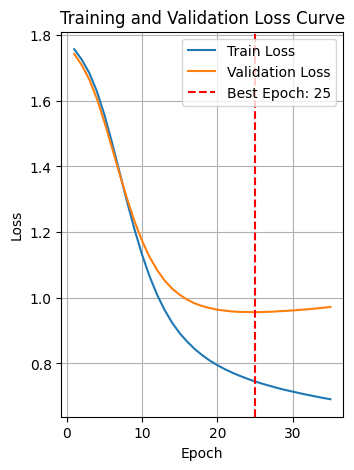

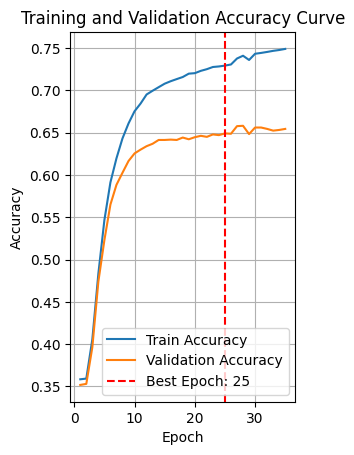

In [ ]:
# -----------------------------
# 9. 最终测试 (使用最优模型)
# -----------------------------
print("\n--- 9. 最终测试 ---")
# 加载验证集上性能最优的模型权重
try:
    model.load_state_dict(torch.load("best_model_lstm.pth"))
    print(f"已加载第 {best_epoch} 个 Epoch 的最优模型进行测试。")
except:
    # 如果没有保存，则使用当前训练结束的模型
    pass

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# -----------------------------
# 10. 结果展示与绘图
# -----------------------------

# 获取类别名称（原始字符串名称）用于报告
# 由于选择了 6 个索引，我们需要从 label_names_all 中获取对应的名称
final_target_names = [label_names_all[i] for i in selected_indices]

print("\n模型分类效果（TF-IDF + LSTM）：")
print(classification_report(all_labels, all_preds, target_names=final_target_names))

# 绘制训练/验证 Loss 曲线
plt.figure(figsize=(8,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss")
plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies)+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, label="Validation Accuracy")
plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()